---
# <font color="#CA3532">Deep Learning Fundamentals and Basic Tools (2026/2027) - Lab Assignment 2</font>
---


* This assignment is centered on the use of [Keras](https://keras.io/).

* Keras is an open-source deep learning library designed to make the development and experimentation of neural networks simple, fast, and intuitive. It provides a user-friendly, modular, and extensible interface.

* Keras can run on top of different computational backends. In this assignment, we will use **TensorFlow** as the backend.

* Throughout the assignment, we will see how easily neural networks can be created with Keras and explore some of the many configuration options available, including network architecture, activation functions, optimizers, and regularization techniques.

### <font color="#CA3532">Instructions</font>

Before You Start the Project

It is strongly recommended that you first clone the entire repository using the following command and read the [`README.md`](https://github.com/samanemami/DLFBT-LAB/blob/main/README.md) file before starting the project.

!git clone https://github.com/samanemami/DLFBT-LAB.git


Keep `lab2_2026.ipynb` and `dlfbt_lab2.py` in the same directory.

### <font color="#CA3532">Imports and reproducibility</font>

In [1]:
import os
import sys
import importlib
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

sys.path.append("../")

import config

solution = importlib.import_module(config.get_source_module(lab_number=1))
solution.set_reproducible(42)

print("Loaded:", Path(solution.__file__).name)

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

Loaded: source.py


## <font color="#CA3532">PART 1 — Phoneme binary classification</font>
 

### <font color="#CA3532">Load and inspect the dataset</font>

In [2]:
X, y = solution.load_phoneme()
overview = solution.dataset_overview(X, y)

print("Samples:", overview["samples"])
print("Features:", overview["features"])
print("Class distribution:", overview["class_distribution"])
print("First 3 rows:\n", X[:3])
print("First 10 labels:", y[:10])

# Tester checks
assert X.ndim == 2
assert y.ndim == 1
assert len(X) == len(y)
assert X.shape[1] == 5
assert set(np.unique(y)).issubset({0.0, 1.0})

Samples: 5404
Features: 5
Class distribution: {0: 3818, 1: 1586}
First 3 rows:
 [[ 1.24   0.875 -0.205 -0.078  0.067]
 [ 0.268  1.352  1.035 -0.332  0.217]
 [ 1.567  0.867  1.3    1.041  0.559]]
First 10 labels: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


### <font color="#CA3532">Train / validation / test split and normalization</font>

**Question.** Why should a scaler be fitted only on the training set?

The validation set is used to make training decisions (e.g. early stopping). The test set is kept untouched until the final evaluation.

In [3]:
split = solution.prepare_data(
    X,
    y,
    test_size=0.20,
    val_size=0.20,
    normalize=True,
)

print("Train:", split.X_train.shape)
print("Validation:", split.X_val.shape)
print("Test:", split.X_test.shape)
print("Training feature means:", np.round(split.X_train.mean(axis=0), 3))
print("Training feature stds: ", np.round(split.X_train.std(axis=0), 3))

# Tester checks
assert split.X_train.shape[1] == X.shape[1]
assert len(split.X_train) + len(split.X_val) + len(split.X_test) == len(X)
assert split.scaler is not None
assert np.allclose(split.X_train.mean(axis=0), 0, atol=1e-5)
assert np.allclose(split.X_train.std(axis=0), 1, atol=1e-4)

Train: (3242, 5)
Validation: (1081, 5)
Test: (1081, 5)
Training feature means: [ 0. -0.  0.  0. -0.]
Training feature stds:  [1. 1. 1. 1. 1.]


### <font color="#CA3532">Baseline MLP</font>

A small MLP is enough for the learning objective. For binary classification, the final layer uses one sigmoid unit and the loss is binary cross-entropy.

In [4]:
nn = solution.build_baseline_model(
    input_dim=split.X_train.shape[1],
    hidden_units=8,
)
solution.compile_binary_model(
    nn,
    optimizer="adam",
    learning_rate=1e-3,
)

nn.summary()

# Tester checks
assert nn.output_shape[-1] == 1
assert nn.layers[-1].activation.__name__ == "sigmoid"
assert nn.loss == "binary_crossentropy"

Model: "baseline_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57 (228.00 B)

 Trainable params: 57 (228.00 B)

 Non-trainable params: 0 (0.00 B)

### <font color="#CA3532">Train with early stopping</font>

In [5]:
history = solution.train_model(
    nn,
    split,
    epochs=250,  # upper bound; early stopping will usually stop earlier
    batch_size=32,
    patience=20,
    verbose=0,
)

print("Epochs actually run:", len(history.history["loss"]))
assert len(history.history["loss"]) <= 250
assert "val_loss" in history.history
assert "val_accuracy" in history.history

Epochs actually run: 250


### <font color="#CA3532">Learning curves</font>

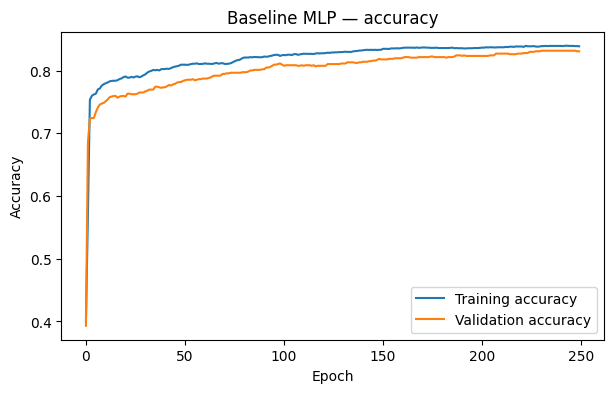

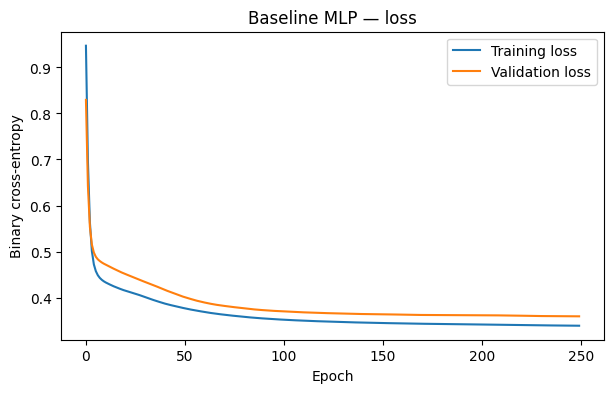

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline MLP — accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy")
plt.title("Baseline MLP — loss")
plt.legend()
plt.show()

### <font color="#CA3532">Held-out evaluation</font>

This is intentionally different from evaluating on all `X, y`: the test set has not participated in fitting, scaling statistics, or early stopping.

In [7]:
baseline_metrics = solution.evaluate_model(nn, split)
print(baseline_metrics)

assert 0.0 <= baseline_metrics["test_accuracy"] <= 1.0
assert baseline_metrics["test_loss"] >= 0.0

{'test_loss': 0.3973199725151062, 'test_accuracy': 0.8094357252120972}


### <font color="#CA3532">Interpretation</font>

Answer briefly:

1. Do training and validation accuracy follow each other?
2. At what point does validation loss stop improving?
3. Is there evidence of underfitting or overfitting?
4. Why is test accuracy a better final estimate here than accuracy computed on the complete dataset?

### <font color="#CA3532">An architecture improvement</font>

Rather than making the network very large, try two small hidden layers and light dropout.

In [8]:
improved_nn = solution.build_improved_model(split.X_train.shape[1])
improved_history = solution.train_model(
    improved_nn,
    split,
    epochs=250,
    batch_size=32,
    patience=20,
    verbose=0,
)
improved_metrics = solution.evaluate_model(improved_nn, split)

print("Baseline:", baseline_metrics)
print("Improved:", improved_metrics)

assert improved_nn.count_params() > nn.count_params()
assert 0.0 <= improved_metrics["test_accuracy"] <= 1.0

Baseline: {'test_loss': 0.3973199725151062, 'test_accuracy': 0.8094357252120972}
Improved: {'test_loss': 0.3528764843940735, 'test_accuracy': 0.8510638475418091}


**Question.** Did the slightly larger model actually improve held-out performance?  
Do not conclude that a larger network is automatically better; compare the validation curves and test metric.

# <font color="#CA3532">PART 2 — Optimization methods</font>

### <font color="#CA3532">Regularization and dropout</font>

In [12]:
regularized_nn = solution.build_regularized_model(
    split.X_train.shape[1], l2_strength=1e-4
)
solution.compile_binary_model(
    regularized_nn,
    "adam",
    learning_rate=1e-3,
)

dropout_nn = solution.build_dropout_model(
    split.X_train.shape[1],
    rate=0.25,
)
solution.compile_binary_model(
    dropout_nn,
    "adam",
    learning_rate=1e-3,
)

assert regularized_nn.output_shape[-1] == 1
assert dropout_nn.output_shape[-1] == 1

print("Regularized parameters:", regularized_nn.count_params())
print("Dropout parameters:", dropout_nn.count_params())

Regularized parameters: 737
Dropout parameters: 737


Train both models with `solution.train_model(...)`, plot their validation losses, and compare them with the baseline.

**Question.** Which method appears to reduce overfitting more effectively on this split?

In [13]:
optimizer_names = [
    "sgd",
    "momentum",
    "nesterov",
    "adagrad",
    "rmsprop",
    "adam",
]

for name in optimizer_names:
    opt = solution.optimizer_from_name(name, learning_rate=1e-3)
    print(f"{name:10s} -> {opt.__class__.__name__}")

# Tester: every requested optimizer must be constructible
assert len(optimizer_names) == 6

sgd        -> SGD
momentum   -> SGD
nesterov   -> SGD
adagrad    -> Adagrad
rmsprop    -> RMSprop
adam       -> Adam


### <font color="#CA3532">Fair optimizer comparison</font>

This cell is intentionally the most computationally expensive one. Start with `epochs=80`; increase it only if needed. Early stopping records how many epochs were actually required.

In [14]:
results = solution.compare_optimizers(
    split,
    names=optimizer_names,
    epochs=80,
    batch_size=32,
    learning_rate=1e-3,
    patience=10,
)

summary = [
    {
        "optimizer": r["optimizer"],
        "epochs": r["epochs_run"],
        "seconds": round(r["seconds"], 3),
        "test_accuracy": round(r["test_accuracy"], 4),
        "test_loss": round(r["test_loss"], 4),
    }
    for r in results
]

summary

[{'optimizer': 'sgd',
  'epochs': 80,
  'seconds': 22.006,
  'test_accuracy': 0.7438,
  'test_loss': 0.471},
 {'optimizer': 'momentum',
  'epochs': 80,
  'seconds': 22.213,
  'test_accuracy': 0.7826,
  'test_loss': 0.4215},
 {'optimizer': 'nesterov',
  'epochs': 80,
  'seconds': 21.728,
  'test_accuracy': 0.7835,
  'test_loss': 0.4215},
 {'optimizer': 'adagrad',
  'epochs': 80,
  'seconds': 22.247,
  'test_accuracy': 0.7391,
  'test_loss': 0.4943},
 {'optimizer': 'rmsprop',
  'epochs': 80,
  'seconds': 21.388,
  'test_accuracy': 0.8039,
  'test_loss': 0.399},
 {'optimizer': 'adam',
  'epochs': 80,
  'seconds': 23.636,
  'test_accuracy': 0.8094,
  'test_loss': 0.3946}]

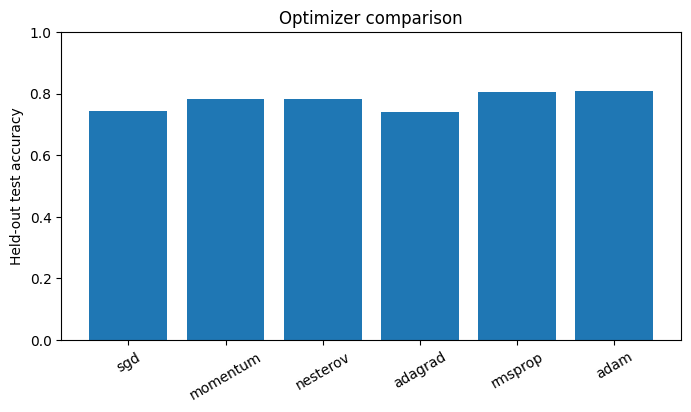

Best on this run: adam | accuracy = 0.8094 | epochs = 80 | seconds = 23.636


In [15]:
names = [r["optimizer"] for r in results]
accuracies = [r["test_accuracy"] for r in results]

plt.figure(figsize=(8, 4))
plt.bar(names, accuracies)
plt.ylim(0, 1)
plt.ylabel("Held-out test accuracy")
plt.title("Optimizer comparison")
plt.xticks(rotation=30)
plt.show()

best = max(results, key=lambda r: r["test_accuracy"])
print(
    "Best on this run:",
    best["optimizer"],
    "| accuracy =", round(best["test_accuracy"], 4),
    "| epochs =", best["epochs_run"],
    "| seconds =", round(best["seconds"], 3),
)

# <font color="#CA3532">PART 2</font>


### <font color="#CA3532">Dataset input</font>


In [ ]:
# Load here your selected dataset considering input and output dimensions

### <font color="#CA3532">Standard choice</font>

- Evaluate the training with a standard choice of cost and activation functions, learning rate, weight initialization and network topology.
- Generate the loss and accuracy figures

In [ ]:
# Code

### <font color="#CA3532">Optimizations</font>

- Evaluate each of the following optimization methods using the same representation and the duration of the training in terms of epochs to reach a choice of error and also in terms of time taken.

 a) Regularization

 b) Dropout

 c) Stochastic gradient descent

 d) Momentum  (including Nesterov version)

 e) AdaGrad

 f) RMSProp

 g) Adam

 h) Optimize

In [ ]:
# a) Regularization

In [ ]:
# b) Dropout

In [ ]:
# c) Stochastic gradient descent

In [ ]:
# d) Momentum  (including Nesterov version)

In [ ]:
# e) AdaGrad

In [ ]:
# f) RMSProp

In [ ]:
# g) Adam

In [ ]:
#  h) Optimize

### <font color="#CA3532">Implement parallelization in Keras with the best optimization</font>






*   Run tests for GPU presence

*   Use your best implementation from the previous exercise here and compare the training time both with GPUs and without GPUs.

Comment all your results.



